<a href="https://colab.research.google.com/github/droyktton/ICNPG/blob/master/Clases/Colaboratory/ThrustRTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Mon Aug 15 22:57:38 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   44C    P8    10W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# ¡Thrust en python!

Esto se logra a través de [ThrustRTC](https://fynv.github.io/ThrustRTC/QuickStartGuide.html), que podemos instalar así

In [ ]:
!pip3 install ThrustRTC

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 763 kB 38.5 MB/s 


**Multiplicar un vector por un escalar**
 
Un primer ejemplo, multiplicar un vector por un escalar en device, usando un kernel de cuda C, pero manejando la memoria de device comodamente con thrust 

In [ ]:
# Python
import ThrustRTC as trtc

kernel = trtc.Kernel(['arr_in', 'arr_out', 'k'],
	'''
	size_t idx = blockIdx.x * blockDim.x + threadIdx.x;
	if (idx >= arr_in.size()) return;
	arr_out[idx] = arr_in[idx]*k;
	''')

dvec_in = trtc.device_vector_from_list([ 1.0, 2.0, 3.0, 4.0, 5.0 ], 'float')
dvec_out = trtc.device_vector('float', 5)
dv_k = trtc.DVFloat(10.0)

kernel.launch( 1,128, [dvec_in, dvec_out, dv_k])
print (dvec_out.to_host())


[10. 20. 30. 40. 50.]


La definicion del kernel es prácticamente la de cuda C, pero argumentos y función empaquetados en strings. El lanzamiento del kernel, kernel.launch acepta la configuración de grilla en los primeros dos argumentos, y los argumentos siguientes son una lista de python de los device_vector y device_values necesarios. 

El kernel o los algoritmos de thrustRTC trabajan sobre sus vectores de device "device_vector", que pueden ser creados a partir de otros en host o en device.

El siguiente ejemplo es lo mismo pero con un kernel simplificado tanto en su definición como en su lanzamiento. Esto se puede usar para kernels simples del tipo ElementWise o basado en loops for sin interdependencias, y nos desligamos de la configuracion de la grilla. 

In [ ]:
# Python
import ThrustRTC as trtc
import numpy as np

forLoop = trtc.For(['arr_in','arr_out','k'], "idx",
	'''
	arr_out[idx] = arr_in[idx]*k;
	''')

dvec_in = trtc.device_vector_from_list( [ 1.0, 2.0, 3.0, 4.0, 5.0 ], 'float')
dvec_out = trtc.device_vector( 'float', 5)
dv_k = trtc.DVFloat(10.0)

forLoop.launch_n( 5, [dvec_in, dvec_out, dv_k])

print (dvec_out.to_host())


[10. 20. 30. 40. 50.]


El "DV" acompañando los tipos se refiere a DeviceViewable. Son los objetos que pueden ser usados como arumentos de los kernels. Ver doc!

**Algoritmos de thrust**

¡Probemos ahora algunos algoritmos de thrust!. Pero todo hecho en thrust, manejo de memoria de device, y algoritmos de device. 

Escribamos primero un código en C++ usando thrust, para luego traducirlo a python usando thrustRTC. Para eso es conveniente instalar el plugin de nvcc

In [ ]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-wlri9hw3
  Running command git clone -q https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-wlri9hw3
  Created wheel for NVCCPlugin: filename=NVCCPlugin-0.0.2-py3-none-any.whl size=4306 sha256=f308ffae406b585f9a2ee11188456e8684c2ea7ee3afc7e983a7468f7f8d261d
  Stored in directory: /tmp/pip-ephem-wheel-cache-3nh8ygwj/wheels/ca/33/8d/3c86eb85e97d2b6169d95c6e8f2c297fdec60db6e84cb56f5e
Successfully built NVCCPlugin


In [ ]:
%load_ext nvcc_plugin


created output directory at /content/src
Out bin /content/result.out


Aquí va el código, que hace varias cosas con tres arrays en device que inicializamos en host y luego movemos a device para realizar las operaciones. 

In [ ]:
%%cu
#include<thrust/host_vector.h>
#include<thrust/device_vector.h>
#include<iostream>

// una funcion conveniente para imprimir los arrays
void print(thrust::device_vector<int> &V, const char *msg)
{
    std::cout << msg << " [ ";
    for(int i=0;i<V.size();i++) std::cout << V[i] << " ";
    std::cout << "]" << std::endl;
}


int main()
{
    thrust::host_vector<int> Xh(10,0),Yh(10,0),Zh(10,0);
    thrust::device_vector<int> X(Xh),Y(Yh),Z(Zh);
 
    // #initialize X to 0,1,2,3, ....
    thrust::sequence(X.begin(),X.end());
    print(X,"X es una secuencia -> ");

    // #compute Y = -X
    thrust::transform(X.begin(),X.end(),Y.begin(), thrust::negate<int>());
    print(Y,"Y es la negacion de X ->");

    // # fill Z with twos
    thrust::fill(Z.begin(),Z.end(),2);
    print(Z,"Z es un array de 2s ->");
  
    // # compute Y = X mod 2
    thrust::transform(X.begin(),X.end(), Z.begin(), Y.begin(), thrust::modulus<int>());
    print(Y,"Y = X mod Z ->");

    // # replace all the ones in Y with tens
    thrust::replace(Y.begin(), Y.end(), 1, 10);
    print(Y,"Y = (Y==1)?(10):(Y) ->");
  
    return 0;
}

X es una secuencia ->  [ 0 1 2 3 4 5 6 7 8 9 ]
Y es la negacion de X -> [ 0 -1 -2 -3 -4 -5 -6 -7 -8 -9 ]
Z es un array de 2s -> [ 2 2 2 2 2 2 2 2 2 2 ]
Y = X mod Z -> [ 0 1 0 1 0 1 0 1 0 1 ]
Y = (Y==1)?(10):(Y) -> [ 0 10 0 10 0 10 0 10 0 10 ]



Traduzcamos ahora el código de arriba en python usando thrustRTC

In [ ]:
# Python
import ThrustRTC as trtc

X = trtc.device_vector('int32_t', 10)
Y = trtc.device_vector('int32_t', 10)
Z = trtc.device_vector('int32_t', 10)

# initialize X to 0,1,2,3, ....
trtc.Sequence(X)
print("X = una secuencia :", X.to_host())

# compute Y = -X
trtc.Transform(X, Y, trtc.Negate())
print("Y = secuencia X negada:", Y.to_host())

# fill Z with twos
trtc.Fill(Z, trtc.DVInt32(2))
print("Z = un vector lleno de 2s:", Z.to_host())

# compute Y = X mod 2
trtc.Transform_Binary(X, Z, Y, trtc.Modulus())
print("Y = X modulo Z:", Y.to_host())

# replace all the ones in Y with tens
trtc.Replace(Y, trtc.DVInt32(1), trtc.DVInt32(10))
print("Y = (Y==1)?(10):(Y) :", Y.to_host())



X = una secuencia : [0 1 2 3 4 5 6 7 8 9]
Y = secuencia X negada: [ 0 -1 -2 -3 -4 -5 -6 -7 -8 -9]
Z = un vector lleno de 2s: [2 2 2 2 2 2 2 2 2 2]
Y = X modulo Z: [0 1 0 1 0 1 0 1 0 1]
Y = (Y==1)?(10):(Y) : [ 0 10  0 10  0 10  0 10  0 10]


Supongamos ahora que veniamos trabajando con los arrays Xh Yh y Zh de numpy en el host, y queremos luego hacer las mismas operaciones 

In [ ]:
# Python
import ThrustRTC as trtc
import numpy as np

# creamos vectores de numpy

#Xh = np.array([0,0,0,0,0,0,0,0,0,0], dtype=np.int32)
#Yh = np.array([0,0,0,0,0,0,0,0,0,0], dtype=np.int32)
#Zh = np.array([0,0,0,0,0,0,0,0,0,0], dtype=np.int32)
Xh = np.empty(10, dtype=np.int32)
Yh = np.empty(10, dtype=np.int32)
Zh = np.empty(10, dtype=np.int32)

# los copiamos a device

X = trtc.device_vector_from_numpy(Xh)
Y = trtc.device_vector_from_numpy(Yh)
Z = trtc.device_vector_from_numpy(Zh)

# initialize X to 0,1,2,3, ....
trtc.Sequence(X)
print("X = una secuencia :", X.to_host())

# compute Y = -X
trtc.Transform(X, Y, trtc.Negate())
print("Y = secuencia X negada:", Y.to_host())

# fill Z with twos
trtc.Fill(Z, trtc.DVInt32(2))
print("Z = un vector lleno de 2s:", Z.to_host())

# compute Y = X mod 2
trtc.Transform_Binary(X, Z, Y, trtc.Modulus())
print("Y = X modulo Z:", Y.to_host())

# replace all the ones in Y with tens
trtc.Replace(Y, trtc.DVInt32(1), trtc.DVInt32(10))

# copiamos el Y en device al array Yh de numpy en el host
Yh = Y.to_host()

print("Y = (Y==1)?(10):(Y) :", Yh)

#ahora uno puede seguir trabajando con Yh de numpy... 



X = una secuencia : [0 1 2 3 4 5 6 7 8 9]
Y = secuencia X negada: [ 0 -1 -2 -3 -4 -5 -6 -7 -8 -9]
Z = un vector lleno de 2s: [2 2 2 2 2 2 2 2 2 2]
Y = X modulo Z: [0 1 0 1 0 1 0 1 0 1]
Y = (Y==1)?(10):(Y) : [ 0 10  0 10  0 10  0 10  0 10]


O sea que es posible y fácil trabajar con numpy arrays en el host y con thrust arrays en el device

Arriba usamos functors predefinidos, pero podemos definirlos nosotros. En el siguiente ejemplo sacamos la raiz cuadrada de los elementos de un vector.

In [ ]:
# Python
import ThrustRTC as trtc
import numpy as np


dvalues = trtc.device_vector_from_list([1.0, 4.0, 9.0, 16.0], 'float')

square_root = trtc.Functor({}, ['x'], 
'''
         return sqrtf(x);
''')

#una transformacion unaria de dvalues
trtc.Transform(dvalues,dvalues, square_root)

print("tipo de vector y dirección: ",dvalues)
print("valores: ",dvalues.to_host())

# notar que to_host trae un array normal
#hvalues = dvalues.to_host()
#hvalues


tipo de vector y dirección:  <ThrustRTC.DVVector.DVVector object at 0x7fbac006eb90>
valores:  [1. 2. 3. 4.]


# Interoperación ThrustRTC con Numba y con Cupy

En el siguiente ejemplo vamos a comenzar con numba arrays en device, los vamos a convertir, pero sin hacer copias device-device!, a thrust arrays. Asi vamos a poder usar sus algoritmos. Los device numba arrays van a estar automaticamente modificados, y los vamos a convertir a cupy arrays, para poder ahora usar los algoritmos de cupy, que complementan a los de thrust.

In [ ]:
# Python
import cupy as cp
import ThrustRTC as trtc
from numba import cuda

#creamos device arrays de numba
Xnumba=cuda.device_array(10,dtype=np.int32)
Ynumba=cuda.device_array(10,dtype=np.int32)
Znumba=cuda.device_array(10,dtype=np.int32)

#los mapeamos
X = trtc.DVNumbaVector(Xnumba)
Y = trtc.DVNumbaVector(Ynumba)
Z = trtc.DVNumbaVector(Znumba)

print("las siguientes operaciones las hacemos con thrustRTC\n")

# initialize X to 0,1,2,3, ....
trtc.Sequence(X)
print("X = una secuencia :", Xnumba.copy_to_host())

# compute Y = -X
trtc.Transform(X, Y, trtc.Negate())
print("Y = secuencia X negada:", Ynumba.copy_to_host())

# fill Z with twos
trtc.Fill(Z, trtc.DVInt32(2))
print("Z = un vector lleno de 2s:", Znumba.copy_to_host())

# compute Y = X mod 2
trtc.Transform_Binary(X, Z, Y, trtc.Modulus())
print("Y = X modulo Z:", Ynumba.copy_to_host())

# replace all the ones in Y with tens
trtc.Replace(Y, trtc.DVInt32(1), trtc.DVInt32(10))
print("Y = (Y==1)?(10):(Y) :", Ynumba.copy_to_host())

# puedo seguir trabajando con numba o thrustRTC... o con cupy!

Xcupy = cp.asarray(Xnumba)
Ycupy = cp.asarray(Ynumba)
Zcupy = cp.asarray(Znumba)

print("\n\ny ahora algunas operaciones las hacemos con cupy:")
print("el maximo de X es ", cp.amax(Xcupy))

fftdeYcupy=cp.array(cp.fft.fft(Ycupy))
print("la transformada de Fourier de Y es ", fftdeYcupy)

las siguientes operaciones las hacemos con thrustRTC

X = una secuencia : [0 1 2 3 4 5 6 7 8 9]
Y = secuencia X negada: [ 0 -1 -2 -3 -4 -5 -6 -7 -8 -9]
Z = un vector lleno de 2s: [2 2 2 2 2 2 2 2 2 2]
Y = X modulo Z: [0 1 0 1 0 1 0 1 0 1]
Y = (Y==1)?(10):(Y) : [ 0 10  0 10  0 10  0 10  0 10]


y ahora algunas operaciones las hacemos con cupy:
el maximo de X es  9


/usr/local/lib/python3.7/dist-packages/cupy/fft/_fft.py:152: UserWarning: cuFFT plan cache is disabled on CUDA 11.1 due to a known bug, so performance may be degraded. The bug is fixed on CUDA 11.2+.
  cache = get_plan_cache()


la transformada de Fourier de Y es  [ 50.+0.j   0.+0.j   0.+0.j   0.+0.j   0.+0.j -50.+0.j   0.+0.j   0.+0.j
   0.+0.j   0.+0.j]


# Un histograma calculado en device

Generamos 20 numeros random usando numpy, luego los transferimos a device, y calculamos el histograma en varios pasos, usando sort, el analogo al counter array, upper_bound y adjacent_difference de thrust.

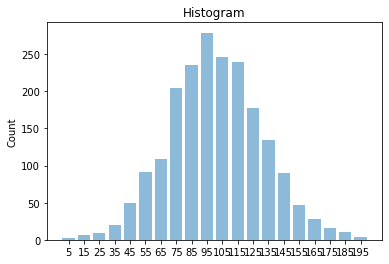

In [ ]:
import cupy as cp
import ThrustRTC as trtc
import matplotlib.pyplot as plt


h_data = np.random.randn(2000).astype(np.float32) * 30.0 +100.0
d_data = trtc.device_vector_from_numpy(h_data)

# ordenamos los valores-> eje X de la dist cumulada
trtc.Sort(d_data)

# una secuencia fake de bins
d_counter = trtc.DVCounter(trtc.DVFloat(0.0), 21)

# multiplicamos la secuencia por 10
d_range_ends = trtc.DVTransform(d_counter, "float", 
    trtc.Functor({}, ['x'], '        return x*10.0;\n' ))

# creacion del histograma acumulado
d_cumulative_histogram =  trtc.device_vector("int32_t", 21)

# calculo del histograma acumulado usando upper bound (vectorized search)
trtc.Upper_Bound_V(d_data, d_range_ends, d_cumulative_histogram)

# creacion y calculo del histograma derivando el acumulado
d_histogram = trtc.device_vector("int32_t", 21)
trtc.Adjacent_Difference(d_cumulative_histogram, d_histogram)
h_histogram = d_histogram.to_host(1, 21)

#graficamos
x_axis = [str(x) for x in np.arange(5, 200, 10)]
positions = np.arange(len(x_axis))
plt.bar(positions, h_histogram, align='center', alpha=0.5)
plt.xticks(positions, x_axis)
plt.ylabel('Count')
plt.title('Histogram')

plt.show()

como era de esperarse ya que

In [ ]:
help(np.random.randn)

# Performance

Retomemos el ejemplo de ordenar un vector aleatorio, que compilabamos en distintos backends.

In [ ]:
%%cuda --name ordenador.cu

#include<cstdlib>
#include<iostream>
#include "/content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/gpu_timer.h"
#include "/content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/cpu_timer.h"

//using namespace thrust;

/*
TODO: includes de thrust
*/
#include<thrust/generate.h>
#include<thrust/transform.h>
#include<thrust/host_vector.h>
#include<thrust/device_vector.h>
#include<thrust/reduce.h>
#include<thrust/sort.h>

typedef float tipo;

int main(int argc, char **argv)
{
  unsigned int N=atoi(argv[1]);

/*
TODO: declarar/alocar vector en host
*/
  thrust::host_vector<tipo> h(N);

/*
TODO: llenarlo de numeros aleatorios entre [0,1]
*/
  using namespace thrust::placeholders;

  //for(int i=0;i < h.size();i++) h[i]=rand();
  thrust::generate(h.begin(),h.end(),rand);
 
  thrust::transform(h.begin(),h.end(),h.begin(),[=](tipo x){return tipo(x/RAND_MAX);});

  #ifdef GPU
  gpu_timer reloj;
  #else
  cpu_timer reloj; 
  #endif

  reloj.tic();

/*
TODO: declarar alocar y copiar array aleatorio a device
*/
  thrust::device_vector<tipo> d(h); 

/*
TODO: ordenar en device
*/
  thrust::sort(d.begin(),d.end());

  tipo min=d[0]; 
  tipo max=d[N-1];

  tipo promedio = thrust::reduce(d.begin(),d.end())/N; 

/*
TODO: calcular el promedio en device
*/

  std::cout << "min=" << min << ", max=" << max << ", promedio=" << promedio << ", ms=" << reloj.tac() << std::endl;
}

'File written in /content/src/ordenador.cu'

In [ ]:
!nvcc -O2 /content/src/ordenador.cu -o GPU -DGPU; cp /content/src/ordenador.cu /content/src/ordenador.cpp; g++ -O2 /content/src/ordenador.cpp -fopenmp -DTHRUST_DEVICE_SYSTEM=THRUST_DEVICE_SYSTEM_OMP -lgomp -I/usr/local/cuda/include/ -o multiCPU; g++ -O2 /content/src/ordenador.cpp -I/usr/local/cuda/include/ -DTHRUST_DEVICE_SYSTEM=THRUST_DEVICE_SYSTEM_CPP  -o singleCPU


/content/src/ordenador.cu:4:10: fatal error: /content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/gpu_timer.h: No such file or directory
 #include "/content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/gpu_timer.h"
          ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
compilation terminated.
/content/src/ordenador.cpp:4:10: fatal error: /content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/gpu_timer.h: No such file or directory
 #include "/content/drive/MyDrive/Classroom/Introducción al Cálculo Numérico en Procesadores Gráficos Materia Optativa/Codigos_de_las_Clases/common/gpu_timer.h"
          ^~~~~~~~~~~~~~~~

In [ ]:
!for prog in GPU multiCPU singleCPU; do printf "$prog \n"; /content/$prog 33554432; printf "======\n\n" ;done; 

GPU 
min=1.72295e-08, max=1, promedio=0.500002, ms=50.9385

multiCPU 
min=1.72295e-08, max=1, promedio=0.531426, ms=1886.83

singleCPU 
min=1.72295e-08, max=1, promedio=0.5, ms=975.255

